# Microproyecto 2 – Clasificación de textos según ODS

Integrantes:
- Jair Leonardo Gonzalez Barreto
- Juan David Villalba Guavita

## Objetivo
Desarrollar una solución, basada en técnicas de procesamiento de lenguaje natural y machine learning, que facilite la interpretación y análisis de información textual para la identificación de relaciones semánticas con los ODS.

# Contexto y datos

## Descripción del problema
Los ODS son los 17 Objetivos de Desarrollo Sostenible de la ONU, una agenda global acordada para 2030 que busca poner fin a la pobreza, proteger el planeta y garantizar paz y prosperidad para todas las personas. En este proyecto se busca desarrollar una solución basada en técnicas de procesamiento del lenguaje natural y machine learning, que permita clasificar automáticamente un texto según los 17 ODS, ofreciendo una forma de presentación de resultados a través de una herramienta de fácil comprensión para el usuario final.

Los 17 ODS se presentan a continación:
| N° | Objetivo                                |
| -- | --------------------------------------- |
| 1  | Fin de la pobreza                       |
| 2  | Hambre cero                             |
| 3  | Salud y bienestar                       |
| 4  | Educación de calidad                    |
| 5  | Igualdad de género                      |
| 6  | Agua limpia y saneamiento               |
| 7  | Energía asequible y no contaminante     |
| 8  | Trabajo decente y crecimiento económico |
| 9  | Industria, innovación e infraestructura |
| 10 | Reducción de las desigualdades          |
| 11 | Ciudades y comunidades sostenibles      |
| 12 | Producción y consumo responsables       |
| 13 | Acción por el clima                     |
| 14 | Vida submarina                          |
| 15 | Vida de ecosistemas terrestres          |
| 16 | Paz, justicia e instituciones sólidas   |
| 17 | Alianzas para lograr los objetivos      |

# Imports y configuración inicial

In [ ]:
import pandas as pd
import numpy as np

import re
import spacy

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Lista básica de stopwords en español (spaCy ya trae una por defecto)
from spacy.lang.es.stop_words import STOP_WORDS
spanish_stopwords = STOP_WORDS

import joblib
import os

In [ ]:
# Cargar modelo de spacy en español
try:
    nlp = spacy.load("es_core_news_sm")
    print("Modelo de spacy cargado correctamente")
except OSError:
    print("El modelo es_core_news_sm no está instalado.")
    print("Instalando el modelo... (esto puede tomar un momento)")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "spacy", "download", "es_core_news_sm"])
    nlp = spacy.load("es_core_news_sm")
    print("Modelo descargado e instalado correctamente")

Modelo de spacy cargado correctamente


## Carga y exploración inicial del dataset

En esta sección cargamos el dataset, verificamos su estructura (columnas, tipos de datos, tamaño) y hacemos una primera exploración de calidad: nulos, duplicados y distribución de las clases ODS.

In [ ]:
ruta_csv = "drohpEPiQPanbXNulDOYQA_c9abe75a30db47a8bef241b84697f3f1_Train_textosODS.csv"
df = pd.read_csv(ruta_csv, sep=";", encoding="utf-8-sig")
df.head()

,textos,ODS
0,"""Aprendizaje"" y ""educación"" se consideran sinó...",4
1,No dejar clara la naturaleza de estos riesgos ...,6
2,"Como resultado, un mayor y mejorado acceso al ...",13
3,Con el Congreso firmemente en control de la ju...,16
4,"Luego, dos secciones finales analizan las impl...",5


## Revisión y limpieza de nulos y duplicados

In [ ]:
# Conteo de nulos por columna
print("Nulos por columna:")
print(df.isna().sum())

# Conteo de filas duplicadas
print("\nFilas duplicadas totales:", df.duplicated().sum())

# Eliminamos duplicados, manteniendo la primera aparición
df = df.drop_duplicates().reset_index(drop=True)

# Eliminamos filas con texto u ODS nulos
df = df.dropna(subset=["textos", "ODS"]).reset_index(drop=True)

print("\nDimensiones después de limpiar nulos y duplicados:", df.shape)


Nulos por columna:
textos    0
ODS       0
dtype: int64

Filas duplicadas totales: 0

Dimensiones después de limpiar nulos y duplicados: (9656, 2)


## Gráfico de distribución de clases:
A continuación, realizamos una primera visualización del número de textos por cada ODS. Así, podremos observar si existe desbalance entre las clases.

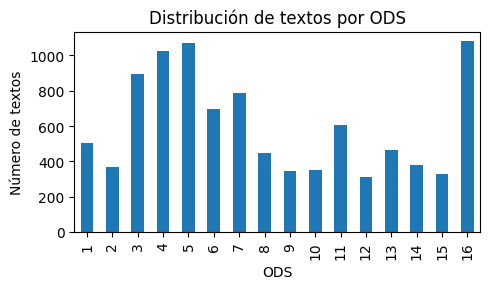

In [ ]:
plt.figure(figsize=(5, 3))
df["ODS"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("ODS")
plt.ylabel("Número de textos")
plt.title("Distribución de textos por ODS")
plt.tight_layout()
plt.show()


# Preparación de los conjuntos de datos
En esta sección separamos la variable independiente `X` (textos) de la variable objetivo `y` (etiqueta ODS) y realizamos la partición en conjuntos de entrenamiento y prueba usando `train_test_split` dejando 20% del conjunto de datos para prueba.

In [ ]:
X = df["textos"]
y = df["ODS"]

print("Ejemplo de X[0]:", X.iloc[0][:200], "...")
print("Ejemplo de y[0]:", y.iloc[0])



Ejemplo de X[0]: "Aprendizaje" y "educación" se consideran sinónimos de escolarización formal. Las organizaciones auxiliares, como las editoriales de educación, las juntas examinadoras y las organizaciones de formació ...
Ejemplo de y[0]: 4


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,        # 20% para prueba
    random_state=42,      # reproducibilidad
    stratify=y            # estratificación para mantener proporción de clases
)

print("Tamaño X_train:", X_train.shape)
print("Tamaño X_test :", X_test.shape)
print("Tamaño y_train:", y_train.shape)
print("Tamaño y_test :", y_test.shape)


Tamaño X_train: (7724,)
Tamaño X_test : (1932,)
Tamaño y_train: (7724,)
Tamaño y_test : (1932,)


El uso de `stratify=y` ayuda a que la distribución de clases en train y test se parezca a la original, lo cual es útil dado que algunos ODS pueden tener menos ejemplos que otros.

# Preprocesamiento de texto

Antes de vectorizar con TF-IDF, aplicamos una etapa de preprocesamiento sobre cada texto:

- Limpieza básica (minúsculas, eliminación de caracteres no alfabéticos).
- Tokenización en palabras.
- Eliminación de stop words con un criterio de frecuencia.
- Lematización (reducir palabras a su forma canónica).

Para simplificar la integración con `TfidfVectorizer`, implementamos una función de preprocesamiento que se usará como `preprocessor` o `tokenizer` dentro del propio vectorizador.


In [ ]:
def limpiar_texto(texto: str) -> str:
    """
    Limpieza mínima antes de tokenizar:
    - Pasar a minúsculas.
    - Eliminar caracteres no alfabéticos.
    - Quitar espacios extra.
    """
    if not isinstance(texto, str):
        return ""

    texto = texto.lower()
    texto = re.sub(r"[^a-záéíóúñü\s]", " ", texto) # Reemplazar cualquier cosa que no sea letra o espacio por espacio
    texto = re.sub(r"\s+", " ", texto).strip()     # Quitar espacios múltiples

    return texto

def preprocesar_texto(texto: str) -> str:
    """
    Aplica:
    - limpieza básica
    - tokenización
    - eliminación de stopwords
    - lematización
    y devuelve un string unido de nuevo por espacios.
    """
    texto_limpio = limpiar_texto(texto)

    if nlp is None or texto_limpio == "":
        return texto_limpio

    doc = nlp(texto_limpio)
    tokens_procesados = []

    for token in doc:
        # Filtrar tokens vacíos, signos, números, etc.
        if token.is_space or token.is_punct or token.like_num:
            continue

        lemma = token.lemma_.strip()
        if lemma == "" or lemma in spanish_stopwords:
            continue

        tokens_procesados.append(lemma)

    return " ".join(tokens_procesados)

# Prueba rápida
ejemplo = X_train.iloc[0]
print("Texto original:", ejemplo[:200], "...")
print("\nTexto preprocesado:", preprocesar_texto(ejemplo)[:200], "...")


Texto original: Por lo tanto, cabe esperar que el aumento de los niveles de ingresos posterior a la reforma de la asistencia social, tanto para los que tienen trabajo como para los que no tienen, tenga un efecto posi ...

Texto preprocesado: caber esperar aumento nivel ingreso posterior reforma asistencia social trabajo efecto positivo niño revisión evidencia reforma bienestar resultado niño unidos waldfogel concluir vulnerable desempeño  ...


# Definición del Pipeline de clasificación ODS

El criterio de “stop words entre 1% y 90%” lo implementaremos directamente en `TfidfVectorizer` con los parámetros `min_df` y `max_df`, que controlan la frecuencia mínima y máxima de los términos en el corpus:

- min_df=0.01 → ignora términos que aparecen en menos del 1% de los documentos.

- max_df=0.90 → ignora términos que aparecen en más del 90% de los documentos.

In [ ]:
# Vectorizador TF-IDF
vectorizer = TfidfVectorizer(
    preprocessor=preprocesar_texto,  # usamos la  función de limpieza+lemmatización
    tokenizer=None,                  # lo dejamos en None porque ya tokenizamos dentro
    ngram_range=(1, 1),              # unigrams
    min_df=0.01,                     # ignora términos en < 1% de los documentos
    max_df=0.90,                     # ignora términos en > 90% de los documentos
    max_features=None,
)

# Reducción de dimensionalidad
svd = TruncatedSVD(
    n_components=200,       # ajustamos según desempeño/memoria
    random_state=42
)

# Clasificador
log_reg = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    n_jobs=-1
)

# Pipeline completo
pipeline_ods = Pipeline(
    steps=[
        ("vectorizer", vectorizer),
        ("dimred", svd),
        ("model", log_reg),
    ]
)

pipeline_ods

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vectorizer', ...), ('dimred', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",<function pre...001672AD972E0>
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


Este Pipeline permite entrenar y reutilizar todo el flujo de preparación +
modelo con una sola llamada a `fit`.

In [ ]:
pipeline_ods.fit(X_train, y_train)

C:\Users\juand\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vectorizer', ...), ('dimred', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",<function pre...001672AD972E0>
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


# Evaluación del modelo sobre el conjunto de prueba

En esta sección evaluamos el desempeño del Pipeline `pipeline_ods` usando el
conjunto de prueba (`X_test`, `y_test`).

Calculamos:
- Métricas de clasificación (`precision`, `recall`, `f1-score`) por ODS.
- Matriz de confusión.
- Probabilidades de pertenencia a cada ODS usando `predict_proba`, pensando en el usuario final (UNFPA/ONU), que necesita ver no solo la clase ganadora sino el nivel de confianza del modelo.


In [ ]:
# Predicciones sobre el conjunto de prueba
y_pred = pipeline_ods.predict(X_test)

print("Reporte de clasificación:\n")
print(classification_report(y_test, y_pred))

Reporte de clasificación:

              precision    recall  f1-score   support

           1       0.83      0.76      0.79       101
           2       0.78      0.77      0.78        74
           3       0.83      0.92      0.87       179
           4       0.91      0.96      0.94       205
           5       0.92      0.94      0.93       214
           6       0.95      0.90      0.92       139
           7       0.86      0.90      0.88       158
           8       0.64      0.55      0.59        89
           9       0.69      0.67      0.68        69
          10       0.72      0.60      0.66        70
          11       0.75      0.82      0.78       122
          12       0.83      0.77      0.80        62
          13       0.85      0.86      0.86        93
          14       0.92      0.79      0.85        75
          15       0.93      0.82      0.87        66
          16       0.92      0.95      0.93       216

    accuracy                           0.85      1932

## Visualización de la matriz de confusión

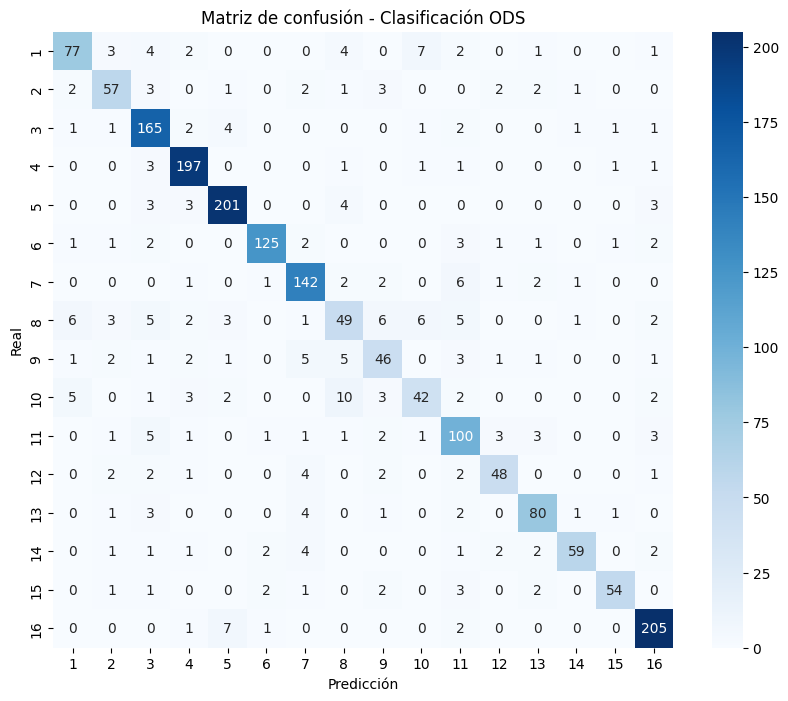

In [ ]:
cm = confusion_matrix(y_test, y_pred)
ods_labels = sorted(y.unique())

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=ods_labels, yticklabels=ods_labels)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - Clasificación ODS")
plt.show()


## Probabilidades de cada clase ODS para el conjunto de prueba

In [ ]:
y_proba = pipeline_ods.predict_proba(X_test)

print("Shape de y_proba:", y_proba.shape)  # (n_muestras_test, n_clases)

# A modo de ejemplo mostramos las probabilidades para las primeras 3 muestras
for i in range(3):
    print(f"\nTexto de prueba {i}:")
    print(X_test.iloc[i][:200], "...")
    print("ODS real:", y_test.iloc[i])
    print("ODS predicho:", y_pred[i])

    # Emparejamos etiquetas y probabilidades
    proba_dict = dict(zip(pipeline_ods.classes_, y_proba[i]))
    # Ordenamos de mayor a menor probabilidad
    proba_ordenada = sorted(proba_dict.items(), key=lambda x: x[1], reverse=True)

    print("Top 5 ODS con mayor probabilidad:")
    for ods, p in proba_ordenada[:5]:
        print(f"  ODS {ods}: {p:.3f}")


Shape de y_proba: (1932, 16)

Texto de prueba 0:
En la última década, muchos de los procesos de paz en el continente africano entre 1991 y 2012 no tuvieron mujeres como mediadoras principales. Maximizar los beneficios de la participación de las muje ...
ODS real: 5
ODS predicho: 5
Top 5 ODS con mayor probabilidad:
  ODS 5: 0.815
  ODS 16: 0.134
  ODS 3: 0.007
  ODS 6: 0.005
  ODS 10: 0.005

Texto de prueba 1:
La seguridad alimentaria se menciona solo una vez, aunque se reconoce la protección de las personas en el sector rural (por ejemplo, la necesidad de proteger a los hogares contra la mala cosecha), per ...
ODS real: 2
ODS predicho: 2
Top 5 ODS con mayor probabilidad:
  ODS 2: 0.437
  ODS 1: 0.134
  ODS 3: 0.066
  ODS 10: 0.063
  ODS 11: 0.047

Texto de prueba 2:
Las políticas de gestión y reciclaje de residuos son todavía relativamente nuevas. Se estima que la tasa de valorización de residuos en Chile fue de aproximadamente 10% en 2009 (CONAMA, 2010). El obje ...
ODS real: 11
ODS p

# Exportación del Pipeline entrenado y uso sobre nuevos textos
Para que el modelo sea reutilizable fuera de este notebook, exportamos el `Pipeline` completo (`TfidfVectorizer` + `TruncatedSVD` + `LogisticRegression`) usando la librería `joblib`.

De esta forma, cualquier sistema externo puede:
1. Cargar el archivo `.joblib`.
2. Enviar un texto en español.
3. Recibir como respuesta el ODS más probable y el vector de probabilidades para las 17 clases.

In [ ]:
modelo_path = "modelo_ods_pipeline.joblib"

# Crear carpeta 'modelos' 
os.makedirs("modelos", exist_ok=True)
modelo_path = os.path.join("modelos", "modelo_ods_pipeline.joblib")

joblib.dump(pipeline_ods, modelo_path)

print(f"Modelo guardado en: {modelo_path}")


Modelo guardado en: modelos\modelo_ods_pipeline.joblib


## Cargar el Pipeline desde disco y probarlo

In [ ]:
# Cargar el modelo desde el archivo
pipeline_cargado = joblib.load(modelo_path)

# Definir un texto de ejemplo para predecir su ODS
texto_nuevo = """
El proyecto busca garantizar el acceso universal al agua potable y saneamiento
adecuado en comunidades rurales, mediante la construcción de infraestructura
hidráulica y programas de educación en higiene.
"""

# Predicción de ODS
ods_predicho = pipeline_cargado.predict([texto_nuevo])[0]
probas = pipeline_cargado.predict_proba([texto_nuevo])[0]

print("Texto de entrada:\n", texto_nuevo)
print("\nODS predicho:", ods_predicho)

# Emparejar ODS y probabilidades para el nuevo texto
proba_dict = dict(zip(pipeline_cargado.classes_, probas))
proba_ordenada = sorted(proba_dict.items(), key=lambda x: x[1], reverse=True)

print("\nTop 5 ODS más probables:")
for ods, p in proba_ordenada[:5]:
    print(f"  ODS {ods}: {p:.3f}")


Texto de entrada:
 
El proyecto busca garantizar el acceso universal al agua potable y saneamiento
adecuado en comunidades rurales, mediante la construcción de infraestructura
hidráulica y programas de educación en higiene.


ODS predicho: 6

Top 5 ODS más probables:
  ODS 6: 0.362
  ODS 9: 0.174
  ODS 4: 0.113
  ODS 11: 0.059
  ODS 7: 0.051


# Discusión de resultados, limitaciones y posibles mejoras

## Resultados obtenidos

El modelo basado en TF-IDF + TruncatedSVD + Regresión Logística logra un
desempeño competitivo en la tarea de clasificación de textos en los 16 ODS,
según las métricas de `precision`, `recall` y `f1-score` sobre el conjunto
de prueba. En general, los ODS con mayor cantidad de ejemplos en el dataset
presentan métricas más altas, mientras que las clases minoritarias muestran
un rendimiento más variable. El uso de probabilidades (`predict_proba`)
permite interpretar mejor la confianza del modelo y es especialmente útil
para el usuario final no técnico (UNFPA/ONU).

## Limitaciones del enfoque actual

Una primera limitación es que el modelo depende fuertemente de la calidad
del preprocesamiento y del lematizador en español; errores en esta etapa
pueden afectar la representación TF-IDF. Además, aunque TruncatedSVD reduce
la dimensionalidad, el espacio de características sigue siendo relativamente
alto y el entrenamiento requiere varios minutos en hardware convencional.
También se observa que algunas clases ODS con pocos ejemplos quedan
infra-representadas, lo que puede sesgar el modelo hacia los ODS más
frecuentes.

## Posibles mejoras futuras

Otra línea de trabajo podría se ajustar hiperparámetros: número de componentes
en `TruncatedSVD`, fuerza de regularización `C` en la Regresión Logística,
y límites de `min_df`/`max_df` para encontrar un mejor compromiso entre
rendimiento y tiempo de entrenamiento. Finalmente, sería interesante comparar
este enfoque clásico con modelos basados en embeddings (por ejemplo,
representaciones pre-entrenadas en español) y aplicar técnicas de manejo de
desbalance de clases (ponderación de clases o muestreo) para mejorar el
desempeño en los ODS menos representados.
